# Import

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from torch.fft import fftn

from tqdm import trange

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.APR_lib as apr

from skimage.filters import gaussian
import brighteyes_ism.simulation.Tubulin_sim as simTub

import scipy
from torch.fft import fftn, ifftn, ifftshift
from scipy.ndimage import shift

# Functions

In [14]:
def model(t, C, tau, T):
    offset = t[len(t)//2]
    modello = C * ( np.heaviside(t-offset, 1) + 1/(np.exp(T/tau) - 1) ) * np.exp((-t+offset)/tau) 
    return modello

def rectangular_IRF(t, dt):
    """
    Rectangular function:
    f(t) = 1/T for 0 <= t <= dt
           0   otherwise
    Works with scalar or NumPy array t.
    """
    t = np.asarray(t)
    offset = t[len(t)//2]
    return np.where((t >= offset-dt) & (t <= offset + dt), 1.0, 0.0)

def partial_convolution_fft(volume: torch.tensor, kernel: torch.tensor, dim1: str = 'ijk', dim2: str = 'jkl',
                        axis: str = 'jk', fourier: tuple = (False, False)):

    dim3 = dim1 + dim2
    dim3 = ''.join(sorted(set(dim3), key=dim3.index))

    dims = [dim1, dim2, dim3]

    axis_list = [[d.find(c) for c in axis] for d in dims]

    if fourier[0] == False:
        volume_fft = fftn(volume, dim=axis_list[0])
    else:
        volume_fft = volume

    if fourier[1] == False:
        kernel_fft = fftn(kernel, dim=axis_list[1])
    else:
        kernel_fft = kernel

    conv = torch.einsum(f'{dim1},{dim2}->{dim3}', volume_fft, kernel_fft)

    conv = ifftn(conv, dim=axis_list[2])  # inverse FFT of the product
    conv = ifftshift(conv, dim=axis_list[2])  # Rotation of 180 degrees of the phase of the FFT
    conv = torch.real(conv)  # Clipping to zero the residual imaginary part

    return conv

def richardson_lucy_deconvolution(ref_data, t, C_R, tau_R, T, iterations=30, eps=1e-4):
        """
        Perform Richardson-Lucy deconvolution channel-wise using FFT-based convolutions and a precomputed kernel.

        Args:
            ref_data (torch.Tensor): Reference data for deconvolution.
            iterations (int): Number of RL iterations (default: 30).
            eps (float): Small value to avoid division by zero (default: 1e-4).

        Side effects:
            Sets self.irf to the deconvolved estimate (shape: [num_samples, num_channels]).

        Raises:
            RuntimeError: If self.kernel is None.
        """
        
        
        # initialize output tensor
        irf_est = torch.ones_like(ref_data) # shape (time)

        # load deconvolution kernel
        kernel =  torch.tensor(model(t, C_R, tau_R, T))
        kernel_t = kernel.clone().flip(0)

        kernel = fftn(kernel, dim=0) # FT of kernel, shape (time,)
        kernel_t = fftn(kernel_t, dim=0)  # FT of time-reversed kernel, shape (time,)

        # Subtract offset
        y = torch.clamp(ref_data, min=0)

        # RL deconvolution
        for _ in range(iterations):
            conv = partial_convolution_fft(irf_est, kernel, dim1='t', dim2='t', axis='t', fourier=(0,1))
            conv = torch.clamp(conv, min=eps)  # avoid div by 0
            relative_blur = y / conv
            correction = partial_convolution_fft(relative_blur, kernel_t, dim1='t', dim2='t', axis='t', fourier=(0,1))
            irf_est = irf_est * correction
            irf_est = torch.clamp(irf_est, min=0)  # enforce positivity

        return irf_est

# Parameters

In [4]:
dt = 0.297619  # ns
nbin = 81
period = nbin * dt
t = np.arange(nbin)*dt
tau = 5
tau_R = 1.5
C = 1e3
C_R = 3e3
dT = 50*dt

In [5]:
irf = rectangular_IRF(t, 2*dt)
irf /= irf.sum()  # Normalize the IRF to have an area of 1

# Tests

In [6]:
pure_model = model(t, C, tau, period)

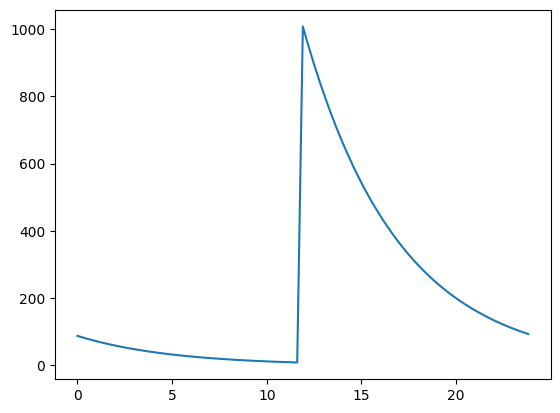

In [7]:
plt.plot(t, pure_model)

In [30]:
ref_model = model(t, C_R, tau_R, period)
ref_model_shifted = shift(ref_model, dT, order=1, mode='grid-wrap')
ref_clean_data = partial_convolution_fft(torch.tensor(ref_model_shifted), torch.tensor(irf), dim1='t', dim2='t', axis='t', fourier=(0,0))
ref_data = np.random.poisson( ref_clean_data )  # Add Poisson noise and shift the data to simulate a delay
ref_data = ref_data / np.sum(ref_data)  # Normalize the reference data to have an area of 1

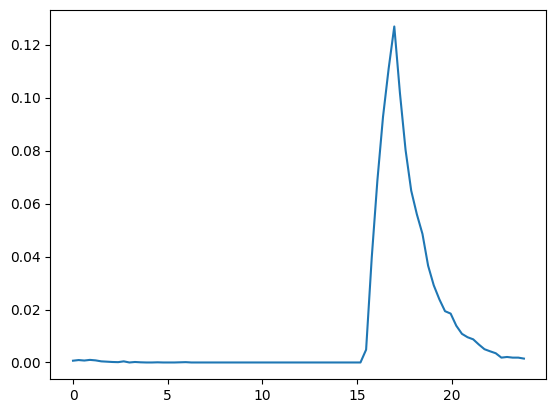

In [38]:
plt.plot(t, ref_data)

In [45]:
est_irf = richardson_lucy_deconvolution(torch.tensor(ref_data), t, C_R, tau_R, period, iterations=200)

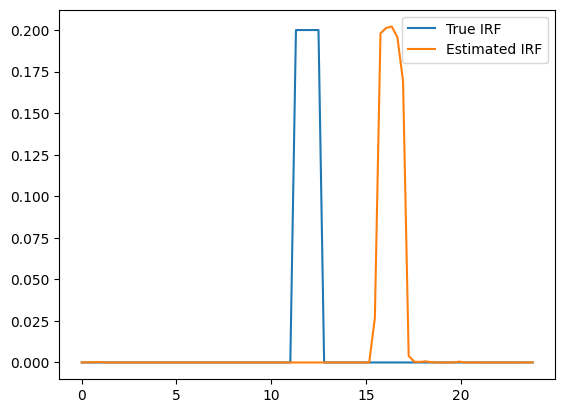

In [46]:
plt.plot(t, irf, label='True IRF')
plt.plot(t, est_irf, label='Estimated IRF')
plt.legend()